# Diabetes Risk Factor Analysis

** Author:** Odoh Ekenedirichukwu Johnpaul

## Problem Statement
As a Registered Nurse with over 5years of Clinical Experience, I have seen how late diabetes diagnosis affects patient outcomes.
This project analyzes the Pima Indians Diabetes Dataset to the answer
** Which Clinical Factors most strongly predict diabetes, and how can healthcare providers use this to prioritize screening?**


## Dataset
768 female patients, 8 clinical features (glucose, BMI, blood pressure, 
insulin, age, etc.) — source: Kaggle (Pima Indians Diabetes Database)


**IMPORT THE LIBRARIES TO USE**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline


**TO LOAD DATA**

In [2]:
#### To load the Dataset

df=pd.read_csv("Diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


**DATA STRUCTURE**

In [3]:
#### To Know the Shape of the dataset

df.shape

(768, 9)

In [4]:
#### To check for the datatype and Misssing values in the
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Data Quality Note
Checked via df.info() and df.describe(): all 768 records are complete (no missing values), and value ranges for clinical fields (e.g. Glucose, 
BMI, BloodPressure) fall within biologically plausible bounds. No cleaning was required — the dataset was pre-processed prior to distribution.

In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [8]:
df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']].mean()

,Glucose,BMI,Age,BloodPressure,Insulin
Outcome,,,,,
0,110.622000,30.846000,31.190000,70.844000,117.172000
1,142.302239,35.398507,37.067164,75.272388,187.615672


### Initial Group Comparison
Diabetic patients show markedly higher average Glucose (+31.7) and Insulin (+70.4) than non-diabetic patients, consistent with insulin resistance as 
a hallmark of Type 2 diabetes. BMI and Age are moderately elevated, while BloodPressure shows the smallest difference between groups — suggesting it 
may be a weaker standalone predictor.

In [27]:
df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']].median()

,Glucose,BMI,Age,BloodPressure,Insulin
Outcome,,,,,
0,107.0,30.1,27.0,70.0,102.5
1,140.0,34.3,36.0,74.5,169.5


In [22]:
from scipy.stats import skew

for col in ['Glucose', 'BMI', 'Insulin', 'Age']:
    print(col, ': skewness =', round(skew(df[col]), 2))

Glucose : skewness = 0.53
BMI : skewness = 0.61
Insulin : skewness = 3.02
Age : skewness = 1.13


**Interpretation:** Glucose and BMI are only mildly skewed, so their means are reliable summaries. Age shows moderate right skew, consistent with a 
younger patient base overall. Insulin is strongly right-skewed (3.02), meaning a small number of high-insulin patients pull the mean upward — for 
this variable, the median is a more robust measure of central tendency than the mean.

In [25]:
from scipy.stats import kurtosis

for col in ['Glucose', 'BMI', 'Insulin', 'Age']:
    print(col, ': kurtosis =', round(kurtosis(df[col]), 2))

Glucose : kurtosis = -0.27
BMI : kurtosis = 0.9
Insulin : kurtosis = 13.76
Age : kurtosis = 0.63


**Additional note:** Insulin's kurtosis (13.76) is exceptionally high, confirming the presence of extreme outliers beyond what skewness alone suggested — a small number of patients with very high insulin readings are heavily influencing this variable's summary statistics.

In [26]:
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Insulin'] < lower_bound) | (df['Insulin'] > upper_bound)]
print("IQR:", IQR)
print("Outlier bounds:", lower_bound, "to", upper_bound)
print("Number of Insulin outliers:", len(outliers))
print("Percentage of dataset:", round(len(outliers) / len(df) * 100, 1), "%")

IQR: 67.0
Outlier bounds: 2.0 to 270.0
Number of Insulin outliers: 51
Percentage of dataset: 6.6 %


**Outlier count:** Using the IQR method, 51 patients (6.6% of the dataset) have Insulin readings above the upper bound of 270, confirming the extreme 
right-skew and high kurtosis observed above. This is a substantial enough group that it could meaningfully influence model coefficients — worth 
flagging for any future modeling work.

**DATA VISUALIZATION**

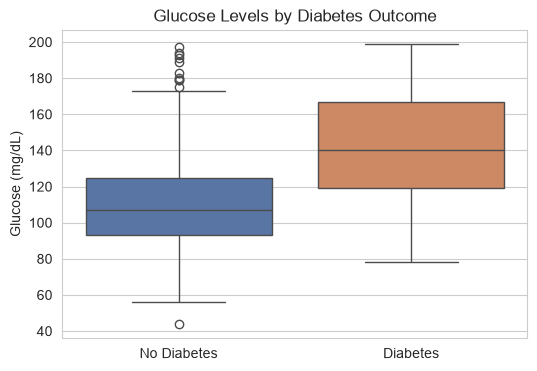

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Glucose', data=df, hue='Outcome', 
            palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('Glucose Levels by Diabetes Outcome')
plt.xlabel('')
plt.ylabel('Glucose (mg/dL)')
plt.show()

**Interpretation:** The boxplot confirms a clear separation in glucose levels between the two groups — the diabetic group's entire interquartile range 
(120-165 mg/dL) sits above the non-diabetic group's median (~110 mg/dL). While some overlap exists, glucose is clearly the strongest single visual 
indicator of diabetes risk in this dataset.

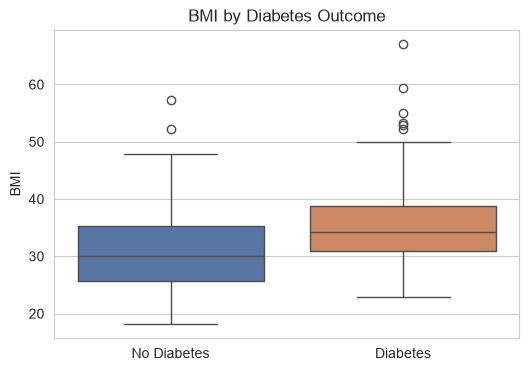

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='BMI', data=df, hue='Outcome', 
            palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('BMI by Diabetes Outcome')
plt.xlabel('')
plt.ylabel('BMI')
plt.show()

**Interpretation:** BMI is elevated in the diabetic group (median ~33-34) compared to non-diabetic patients (median ~30), but the overlap between 
groups is larger than with glucose — meaning BMI alone is a weaker standalone predictor, though it likely adds value in combination with 
other factors.

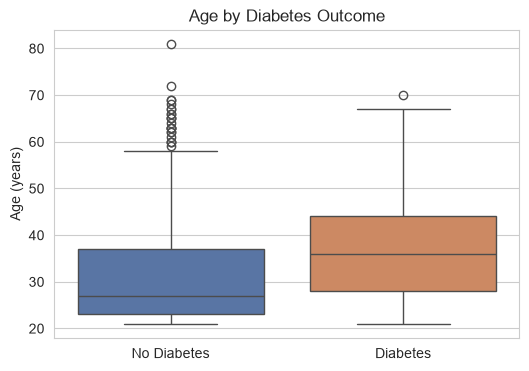

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Age', data=df, hue='Outcome', 
            palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('Age by Diabetes Outcome')
plt.xlabel('')
plt.ylabel('Age (years)')
plt.show()

**Interpretation:** Diabetic patients are, on average, older (median ~35-36) than non-diabetic patients (median ~27), consistent with diabetes risk 
increasing with age. However, notable overlap exists — a meaningful number of younger patients in the dataset also have diabetes, suggesting age alone does not fully explain risk.

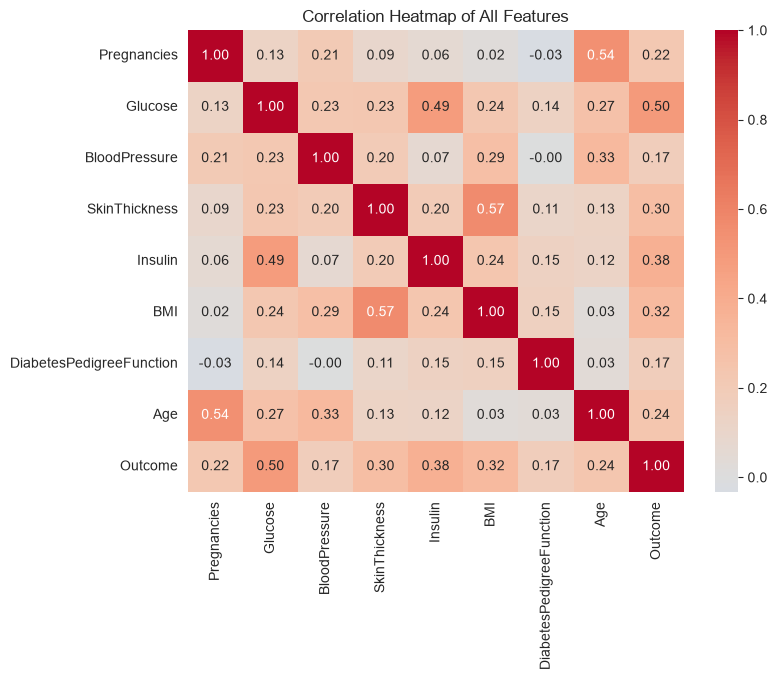

In [13]:
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of All Features')
plt.show()

**Interpretation:** The correlation heatmap confirms the patterns seen in the boxplots above. Glucose has the strongest correlation with diabetes Outcome (0.50), followed by Insulin (0.38) and BMI (0.32). BloodPressure shows the weakest correlation (0.17), consistent with its minimal separation in the earlier boxplot. Notably, SkinThickness and BMI are strongly correlated with each other (0.57), as are Age and Pregnancies (0.54) — both physiologically expected relationships, and worth keeping in mind if this data were used for predictive modeling (multicollinearity).

## Predictive Modeling 
To validate the findings above numerically, a simple logistic regression 
model was built to predict diabetes Outcome from the clinical features.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [18]:
### SCALE FEATURES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
### TO TRAIN THE MODEL

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [20]:
### TO EVALUATE ON TEST DATA

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7727272727272727

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [21]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

coefficients

,Feature,Coefficient
1,Glucose,0.919647
5,BMI,0.437242
4,Insulin,0.406573
3,SkinThickness,0.380110
7,Age,0.376666
0,Pregnancies,0.221502
6,DiabetesPedigreeFunction,0.178149
2,BloodPressure,-0.111990


## Model Summary
A logistic regression model achieved 77% accuracy predicting diabetes Outcome from the 8 clinical features. However, recall for diabetic patients 
was only 65% — meaning roughly 1 in 3 diabetic patients were missed. Given the clinical cost of a false negative in a screening context, this is more 
important than the accuracy figure alone.

Feature importance confirms the earlier analysis: **Glucose** is by far the strongest predictor (coefficient 0.92), followed by BMI (0.44) and Insulin (0.41). BloodPressure contributed almost nothing (-0.11), consistent with its weak correlation and minimal separation in the boxplot.

## Recommendations
- Prioritize glucose and BMI screening as the strongest indicators.
- Given the model's lower recall for diabetic cases, this should be treated as a screening aid, not a diagnostic tool — flagged patients would still 
  need clinical follow-up rather than relying on the model alone.
- Future work: address class imbalance (e.g. class weighting or resampling) to improve recall for the diabetic class specifically.

## Tools Used
Python (pandas, numpy, matplotlib, seaborn, scikit-learn) in Jupyter Notebook.